In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\bisha\OneDrive\Desktop\week1\Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


There are 545 rows and 13 columns in this dataset. In 13 columns, 7 are categorical and 6 are integer. We have to convert these 7 columns into integer through one hot encoding.

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

There is no null value or missing value in this dataset 

In [7]:
df.duplicated().sum()

0

There is no duplicate data in this dataset so we have nothing to remove.

In [8]:
for col in df.columns:
    if df[col].dtype == "object":
        print(df[col].unique())

['yes' 'no']
['no' 'yes']
['no' 'yes']
['no' 'yes']
['yes' 'no']
['yes' 'no']
['furnished' 'semi-furnished' 'unfurnished']


In [9]:
df = pd.get_dummies(df,dtype=int, drop_first=True)

In [10]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [11]:
df = df.astype(int)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


Now Our data is prepared for model building. But before it we try to visualise some insight from data through graphs.

## Visualisation

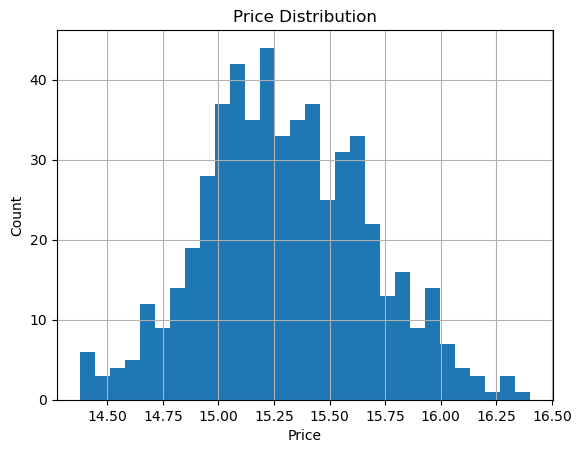

In [13]:
np.log1p(df["price"]).hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

The dataset contains high number of house which is in median range

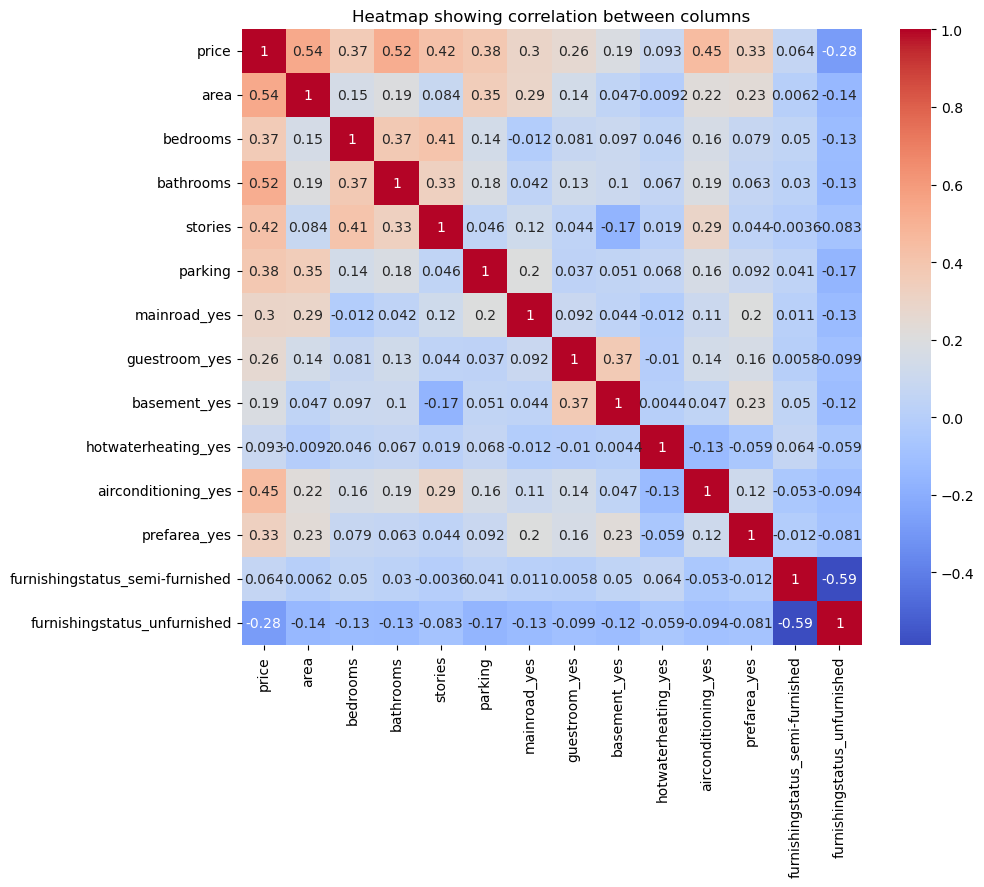

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Heatmap showing correlation between columns")
plt.show()

Correlation map shows how colums are related.
### Insights:-
- Larger houses tend to have higher prices.
- Houses with more bathrooms and stories are generally more expensive.
- Air conditioning appears to significantly increase house prices.
- Parking availability also contributes positively to price.
- One important insight is area is highly correleated with rate it means it highly influence price.
- Bedrooms have weaker correlation than area.
- This suggests house size matters more than simply the number of rooms.


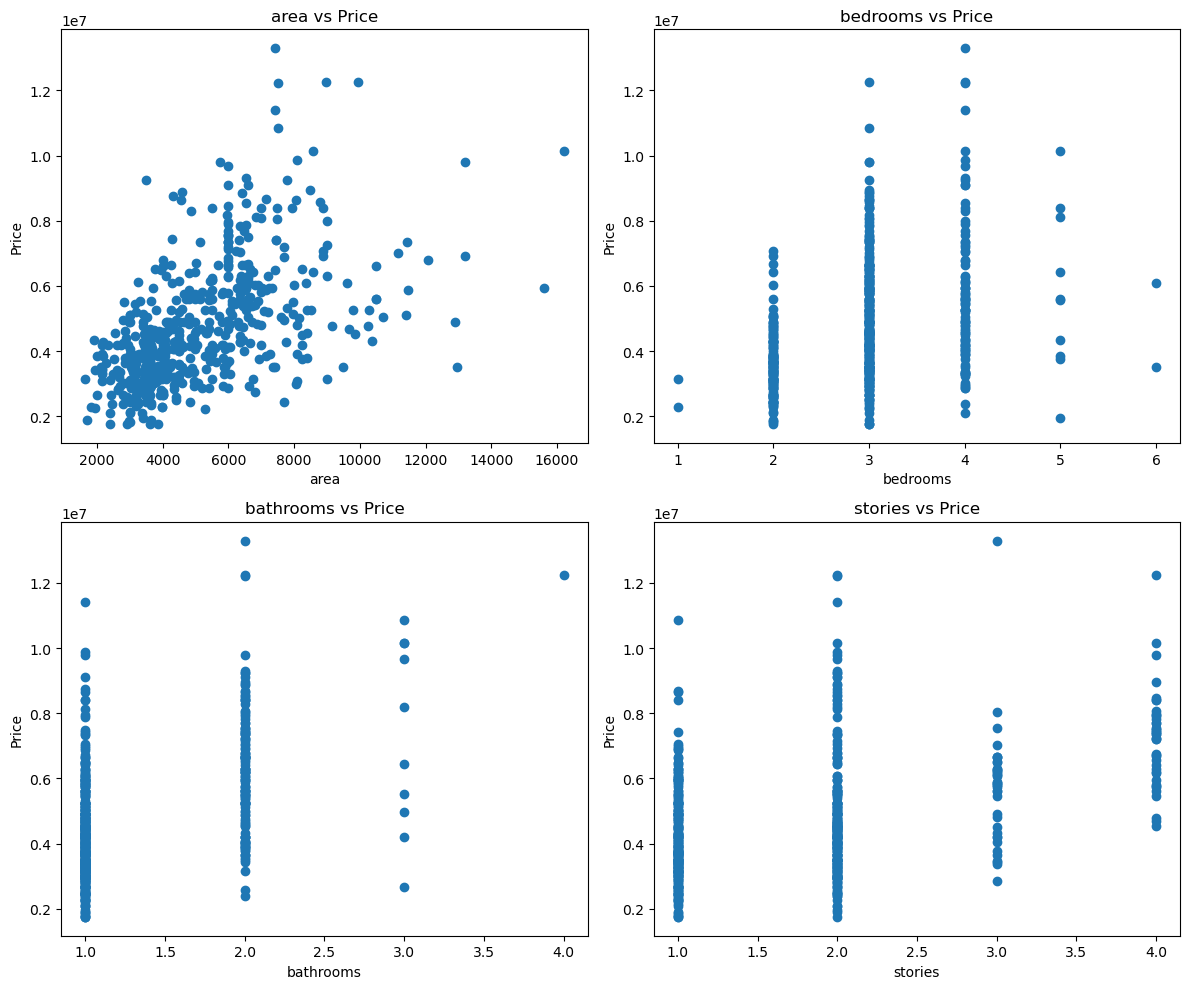

In [15]:
cols = ["area", "bedrooms", "bathrooms", "stories"]

plt.figure(figsize=(12, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.scatter(df[col], df["price"])
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.title(f"{col} vs Price")

plt.tight_layout()
plt.show()

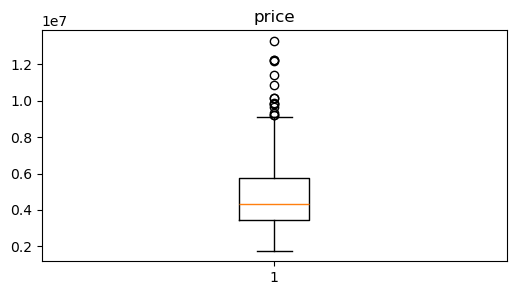

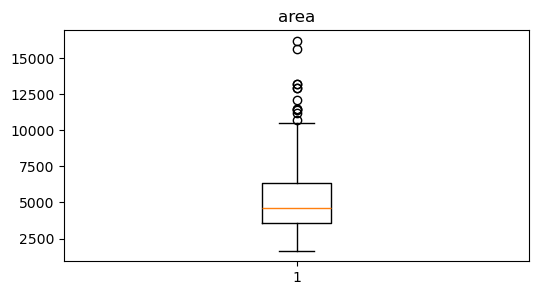

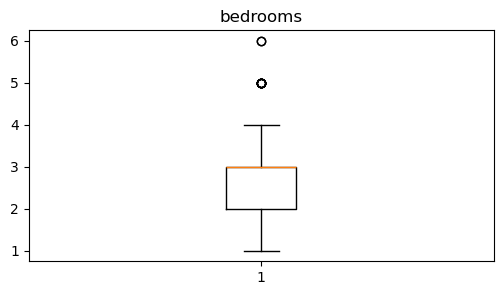

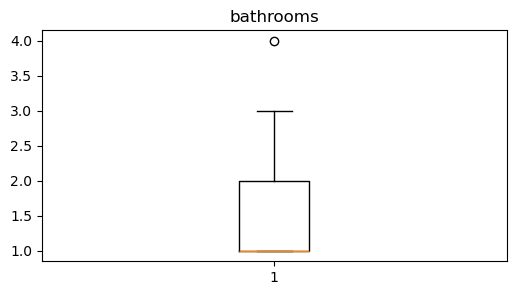

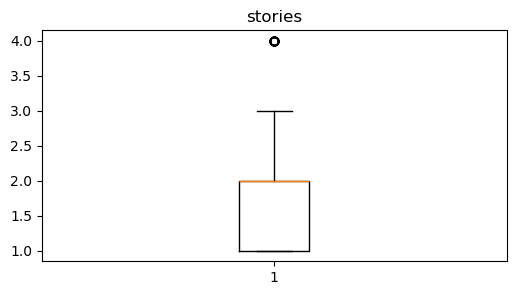

In [16]:
cols = ["price", "area", "bedrooms", "bathrooms", "stories"]

for col in cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

### Insights
Some houses are significantly more expensive than others.

Possible reasons:

- Luxury homes
- Premium locations
- Special amenities
- Good connectivity

Area has outliers but we do not delete it because it impact on our result and make model biased.

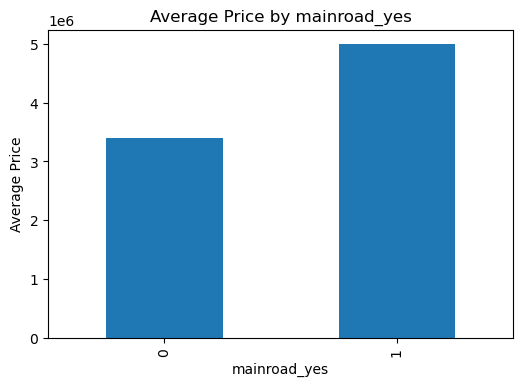

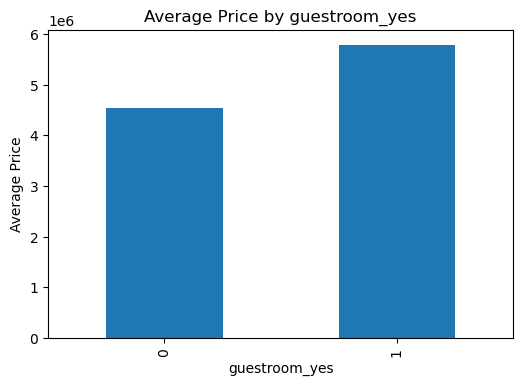

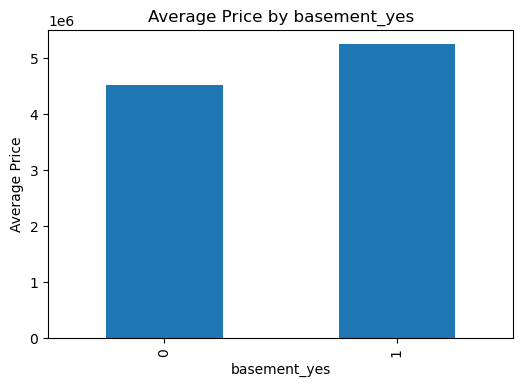

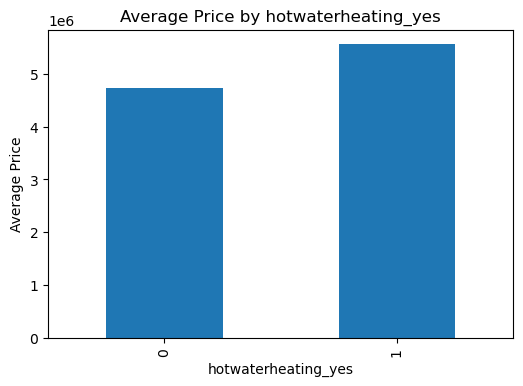

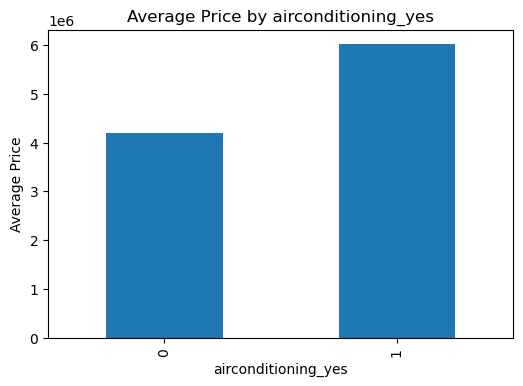

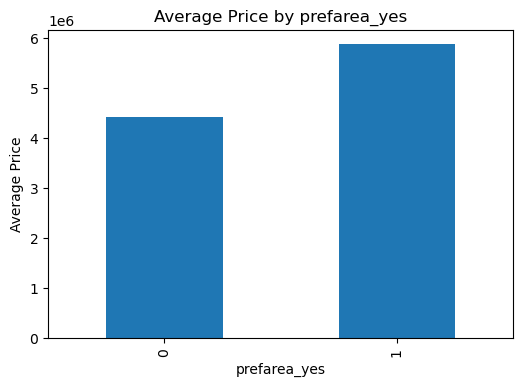

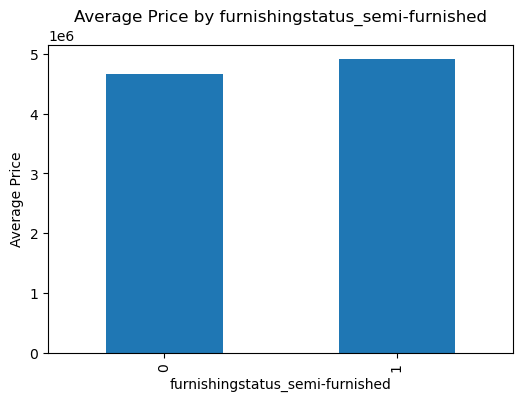

In [17]:
categorical_cols = [
    'mainroad_yes',
    'guestroom_yes',
    'basement_yes',
    'hotwaterheating_yes',
    'airconditioning_yes',
    'prefarea_yes',
    'furnishingstatus_semi-furnished'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))

    df.groupby(col)['price'].mean().plot(kind='bar')

    plt.title(f'Average Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Average Price')

    plt.show()

# Insights:-
- It shows clearly if we give more features like air conditioning, basement, etc. The prices of houses increase.

## Models Building

In [18]:
x = df.drop("price", axis=1)
y = df["price"]

In [19]:
x.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [20]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             545 non-null    int32
 1   bedrooms                         545 non-null    int32
 2   bathrooms                        545 non-null    int32
 3   stories                          545 non-null    int32
 4   parking                          545 non-null    int32
 5   mainroad_yes                     545 non-null    int32
 6   guestroom_yes                    545 non-null    int32
 7   basement_yes                     545 non-null    int32
 8   hotwaterheating_yes              545 non-null    int32
 9   airconditioning_yes              545 non-null    int32
 10  prefarea_yes                     545 non-null    int32
 11  furnishingstatus_semi-furnished  545 non-null    int32
 12  furnishingstatus_unfurnished     545 non-null    i

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [24]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

In [25]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² :", r2_lr)

Linear Regression
MAE : 970043.4039201644
RMSE: 1324506.9600914405
R² : 0.6529242642153175


R2 score is 0.65, which mean model explain 65% variance in house price which is good score. 

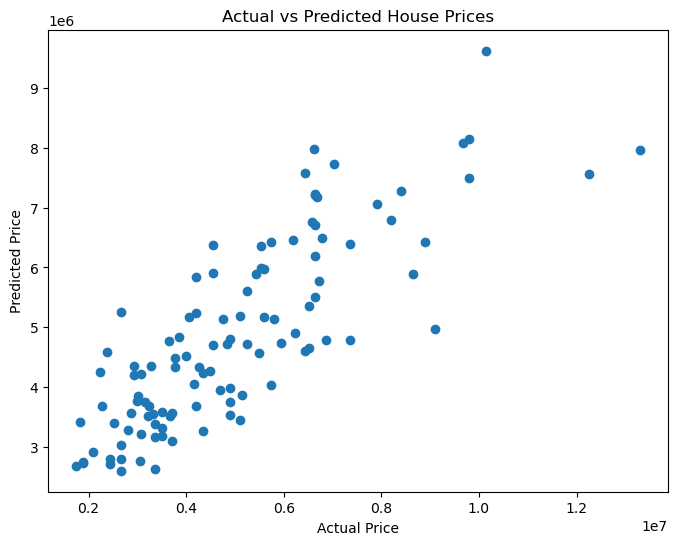

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Random Forest

In [27]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [28]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

Random Forest
MAE : 1021151.0811926605
RMSE: 1399758.195088448
R² : 0.6123660550314123


R2 score is 0.61, which means the model explains 61% of the variance in house prices, which is a good score. But not good than linear regression model also mean absolute error is high for random forest model.

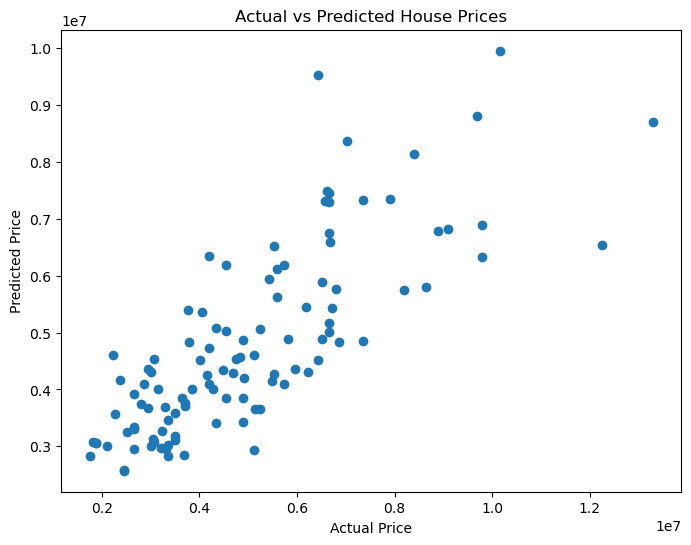

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Summary
The analysis showed that area is the most important factor influencing house prices, followed by the number of bathrooms, stories, parking spaces, and amenities such as air conditioning and preferred location. The Linear Regression model was able to explain about 65% of the variation in house prices, which indicates a reasonably good level of accuracy for real-world data. One surprising finding was that the number of bedrooms alone had a weaker impact on price than expected, while features such as location and house size played a much larger role. The data also contained a few luxury-property outliers with exceptionally high prices.

# Business Idea:-
Based on these findings, a real estate business should focus on larger properties in preferred areas and invest in amenities like parking and air conditioning, as these features are associated with higher property values.